In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('results/forecasts_final.csv')
df['ds'] = pd.to_datetime(df['ds'])

models = [
    'Naive', 'SeasonalNaive', 'AutoETS', 'AutoTheta', 
    'CatBoost_Recursive', 'CatBoost_Direct', 'PatchTST'
]

display(df.head())

,unique_id,ds,y,step,Naive,SeasonalNaive,AutoETS,AutoTheta,CatBoost_Recursive,CatBoost_Direct,PatchTST
0,T10017,2042-08-31,11928.33,1,11709.83,10304.65,11730.959646,11741.715368,11381.114720,11366.098345,11710.594
1,T10017,2042-09-30,12019.13,2,11709.83,10460.18,11752.107407,11756.655341,11381.114720,11435.075670,11730.861
2,T10017,2042-10-31,11914.27,3,11709.83,10595.11,11773.255168,11736.888358,11750.832840,11230.231782,11702.870
3,T10017,2042-11-30,12095.58,4,11709.83,10774.82,11794.402930,11768.135519,11655.764826,11530.131417,11741.460
4,T10017,2042-12-31,12218.36,5,11709.83,11038.85,11815.550691,11789.625578,11657.276778,11128.564664,11717.075


In [ ]:
def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(numerator / (denominator + 1e-9)) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-9) * 100

In [15]:
global_metrics_list = []

for model in models:
    valid_mask = df[model].notna() & df['y'].notna()
    y_t = df.loc[valid_mask, 'y']
    y_p = df.loc[valid_mask, model]
    
    global_metrics_list.append({
        'Model': model,
        'sMAPE, %': smape(y_t, y_p),
        'WAPE, %': wape(y_t, y_p)
    })

global_df = pd.DataFrame(global_metrics_list).sort_values(by='WAPE, %').reset_index(drop=True)
display(global_df.round(2))

,Model,"sMAPE, %","WAPE, %"
0,AutoTheta,13.84,13.74
1,AutoETS,14.17,14.49
2,CatBoost_Direct,15.28,14.99
3,CatBoost_Recursive,14.61,15.01
4,Naive,15.42,15.84
5,PatchTST,15.54,16.03
6,SeasonalNaive,16.56,16.53


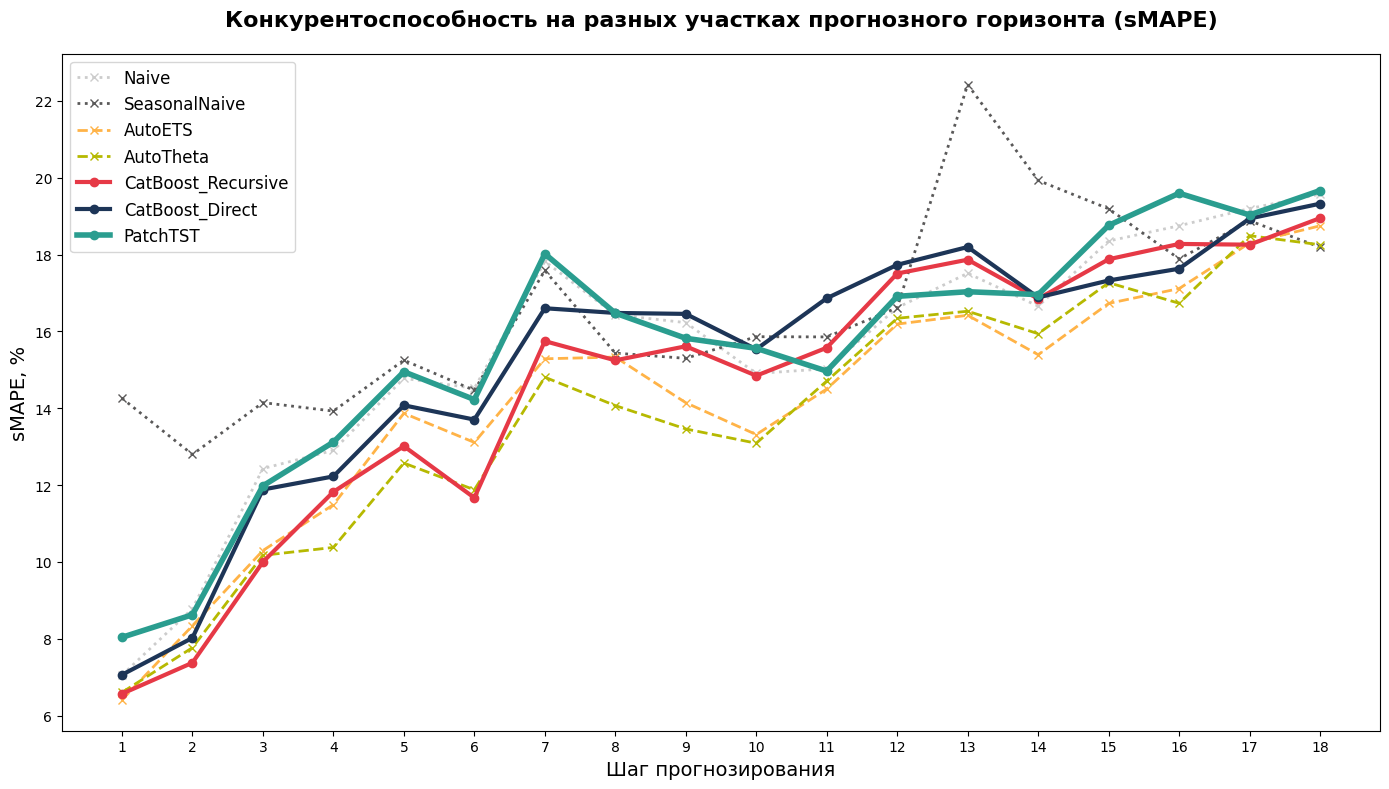

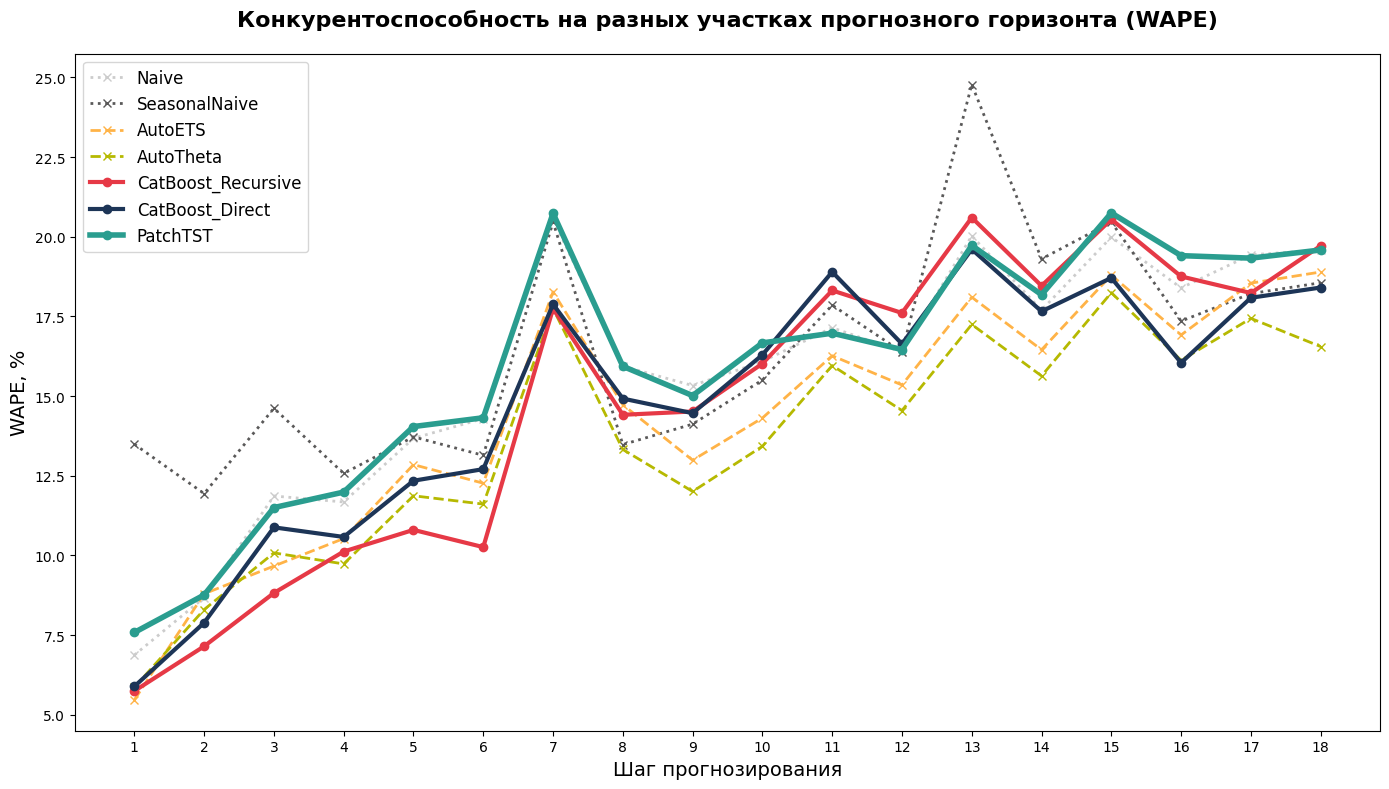

In [ ]:
step_metrics_smape = pd.DataFrame(index=range(1, df['step'].max() + 1))
step_metrics_wape = pd.DataFrame(index=range(1, df['step'].max() + 1))

for model in models:
    smape_scores = []
    wape_scores = []
    for step in step_metrics_smape.index:
        step_df = df[df['step'] == step]
        valid_mask = step_df[model].notna() & step_df['y'].notna()
        y_t = step_df.loc[valid_mask, 'y']
        y_p = step_df.loc[valid_mask, model]
        
        smape_scores.append(smape(y_t, y_p))
        wape_scores.append(wape(y_t, y_p))
        
    step_metrics_smape[model] = smape_scores
    step_metrics_wape[model] = wape_scores


colors = {
    'Naive': '#cccccc', 'SeasonalNaive': "#5A5959", 
    'AutoETS': '#ffb347', 'AutoTheta': "#b6b901",
    'CatBoost_Recursive': '#e63946', 
    'CatBoost_Direct': '#1d3557',    
    'PatchTST': '#2a9d8f'            
}

line_styles = {
    'Naive': ':', 'SeasonalNaive': ':', 
    'AutoETS': '--', 'AutoTheta': '--',
    'CatBoost_Recursive': '-', 'CatBoost_Direct': '-', 'PatchTST': '-'
}

line_widths = {
    'Naive': 2, 'SeasonalNaive': 2, 
    'AutoETS': 2, 'AutoTheta': 2,
    'CatBoost_Recursive': 3, 'CatBoost_Direct': 3, 'PatchTST': 3
}

def plot_step_metrics(step_df, metric_label, title):
    plt.figure(figsize=(14, 8))
    for model in models:
        plt.plot(step_df.index, step_df[model], 
                 label=model, 
                 color=colors[model], 
                 linestyle=line_styles[model],
                 linewidth=line_widths[model],
                 marker='o' if line_styles[model] == '-' else 'x')

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Шаг прогнозирования', fontsize=14)
    plt.ylabel(metric_label, fontsize=14)
    plt.xticks(step_df.index)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_step_metrics(step_metrics_smape, 'sMAPE, %', 'Конкурентоспособность на разных участках прогнозного горизонта (sMAPE)')
plot_step_metrics(step_metrics_wape, 'WAPE, %', 'Конкурентоспособность на разных участках прогнозного горизонта (WAPE)')